# Визуализация результатов eval: наш ORB vs OpenCV ORB

Читает JSON из `eval_manual_orb.py` и строит графики.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# === ПУТЬ К JSON ===
JSON_PATH = Path('output/pyramid_smoke.json')  # поменяй, если нужно

with open(JSON_PATH) as f:
    report = json.load(f)

print('Config:')
for k, v in report['config'].items():
    print(f'  {k}: {v}')
print()
print('Methods:', list(report['methods'].keys()))

Config:
  dataset: /home/meg8egb/IT/Yandex/SotA/metrics/data/hpatches-sequences-release
  sequences: 116
  max_keypoints: 1000
  fast_threshold: 20
  thresholds: [1, 2, 3, 4, 5]
  limit_sequences: None
  orientation: True

Methods: ['fast-pyramid', 'opencv-orb']


## 1. Сводная таблица

In [2]:
thresholds = report['methods'][list(report['methods'].keys())[0]]['thresholds_px']
groups = ['all', 'illumination', 'viewpoint']

rows = []
for method, data in report['methods'].items():
    for group in groups:
        s = data['summary'].get(group, {})
        if not s:
            continue
        row = {
            'method': method,
            'group': group,
            'pairs': s.get('pairs'),
            'mean_matches': s.get('mean_matches'),
            'mean_kp': data.get('mean_keypoints'),
            'extraction_ms': data.get('mean_extraction_ms'),
        }
        for t in thresholds:
            for metric in ['MMA', 'MHA', 'MS']:
                row[f'{metric}@{t:g}'] = s.get(f'{metric}@{t:g}')
        rows.append(row)

df = pd.DataFrame(rows)
print(df[['method', 'group', 'pairs', 'mean_matches', 'mean_kp', 'extraction_ms']].to_string(index=False))

      method        group  pairs  mean_matches    mean_kp  extraction_ms
fast-pyramid          all    580    297.200000 921.777299     773.360300
fast-pyramid illumination    285    289.312281 921.777299     773.360300
fast-pyramid    viewpoint    295    304.820339 921.777299     773.360300
  opencv-orb          all    580    369.674138 991.905172      37.623291
  opencv-orb illumination    285    374.003509 991.905172      37.623291
  opencv-orb    viewpoint    295    365.491525 991.905172      37.623291


## 2. Bar chart: MMA / MHA / MS при пороге 3px

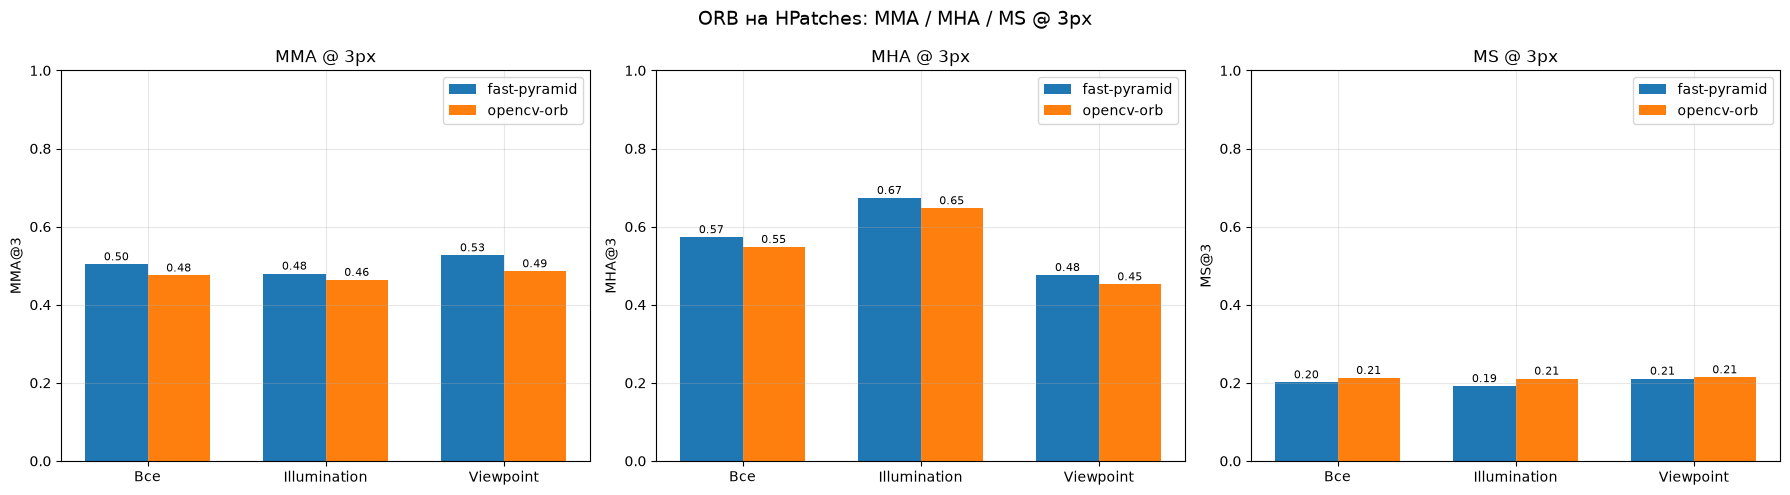

In [3]:
T = 3
metrics = ['MMA', 'MHA', 'MS']
methods = list(report['methods'].keys())
groups_ru = {'all': 'Все', 'illumination': 'Illumination', 'viewpoint': 'Viewpoint'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    x = np.arange(len(groups))
    width = 0.35
    for i, method in enumerate(methods):
        vals = [df[(df['method'] == method) & (df['group'] == g)][f'{metric}@{T}'].values[0]
                for g in groups]
        offset = (i - len(methods)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=method)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}',
                    ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([groups_ru[g] for g in groups])
    ax.set_ylabel(f'{metric}@{T}')
    ax.set_title(f'{metric} @ {T}px')
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle(f'ORB на HPatches: MMA / MHA / MS @ {T}px', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Кривые метрик по порогам (1–5 px)

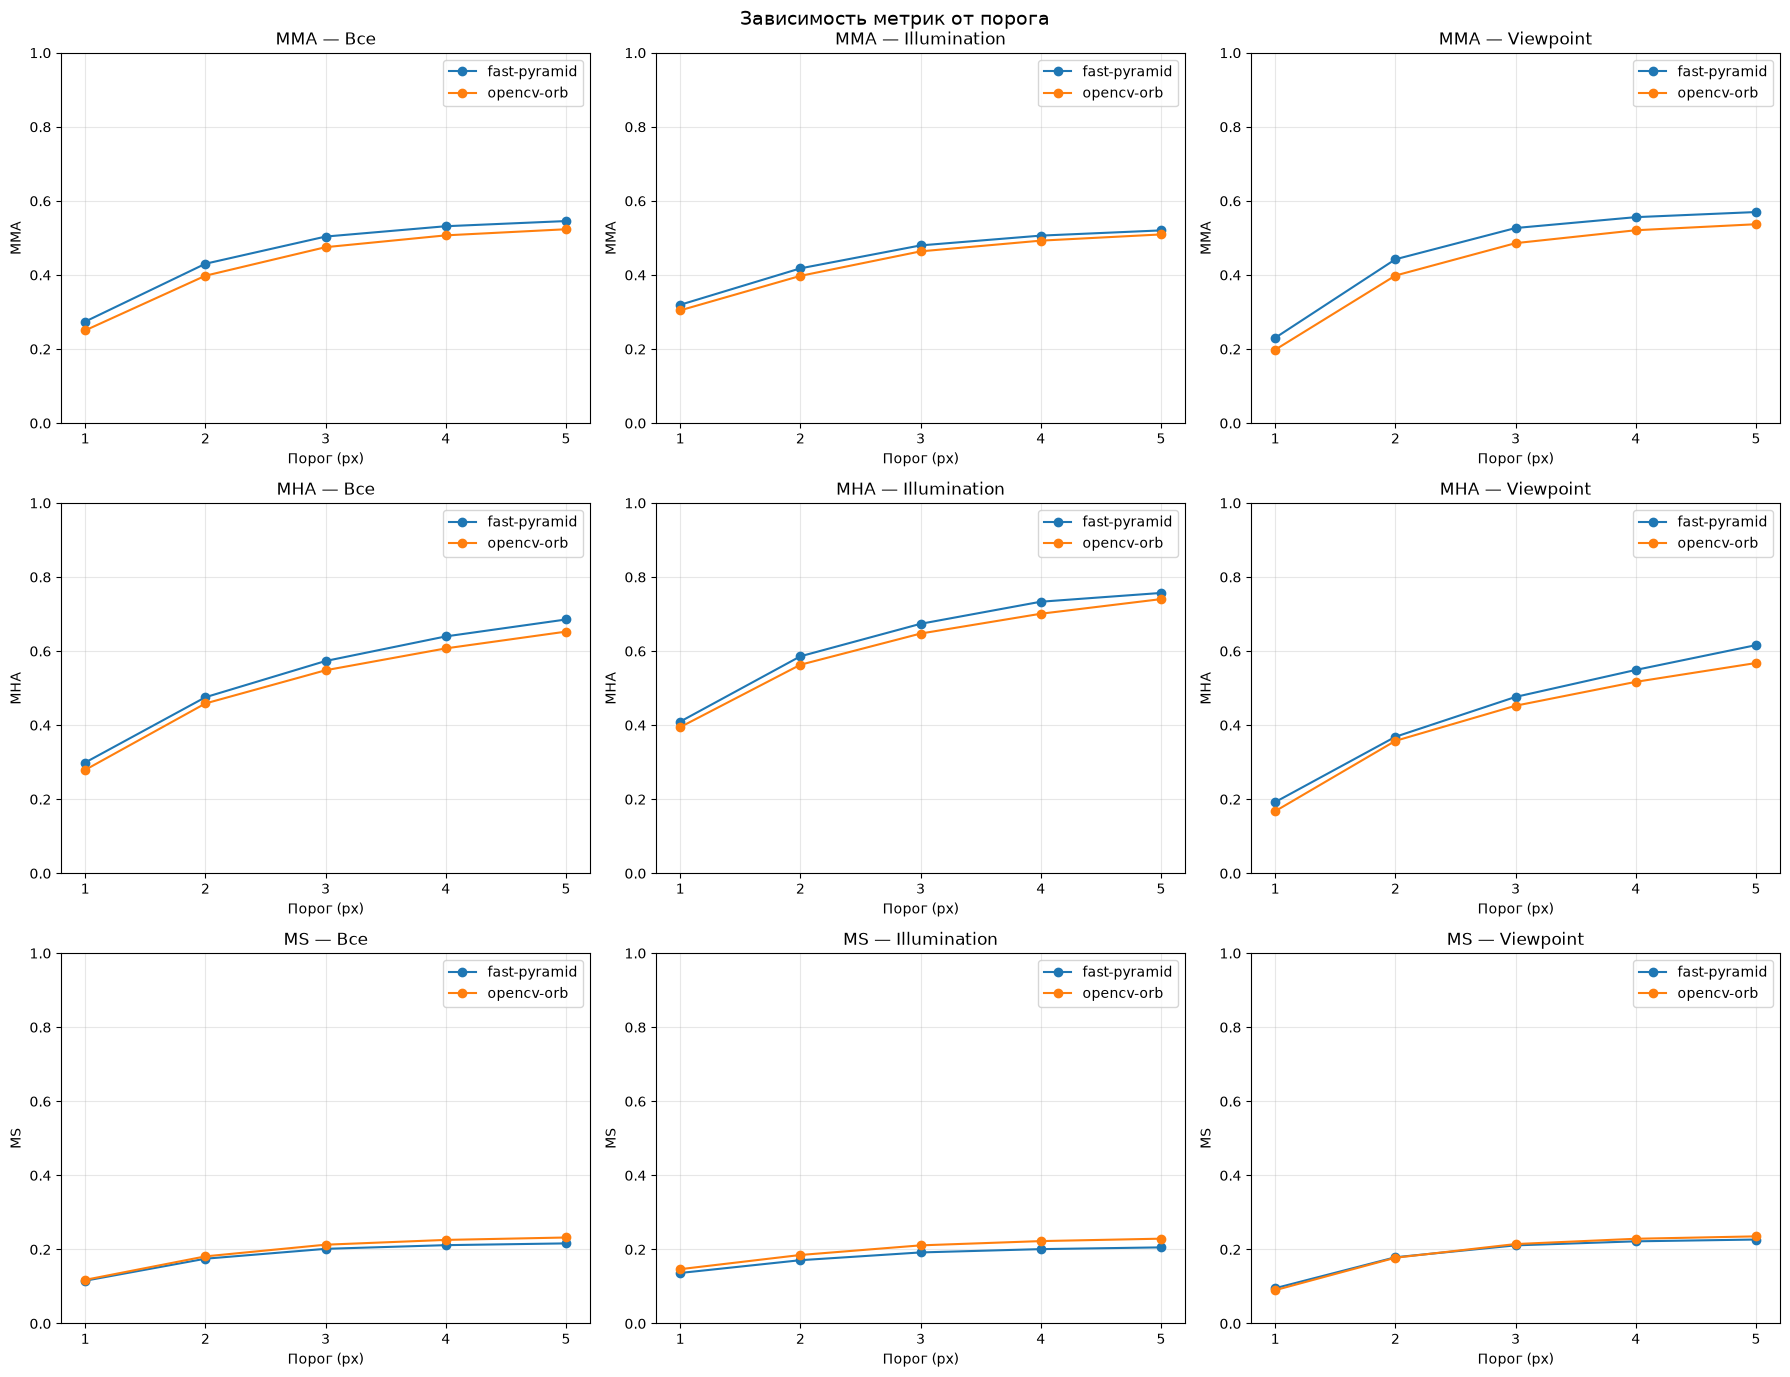

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for i, metric in enumerate(metrics):
    for j, group in enumerate(groups):
        ax = axes[i][j]
        for method in methods:
            row = df[(df['method'] == method) & (df['group'] == group)].iloc[0]
            vals = [row[f'{metric}@{t:g}'] for t in thresholds]
            ax.plot(thresholds, vals, 'o-', label=method)
        ax.set_xlabel('Порог (px)')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} — {groups_ru[group]}')
        ax.legend()
        ax.set_xticks(thresholds)
        ax.set_ylim(0, 1)

plt.suptitle('Зависимость метрик от порога', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Гистограмма числа матчей по парам

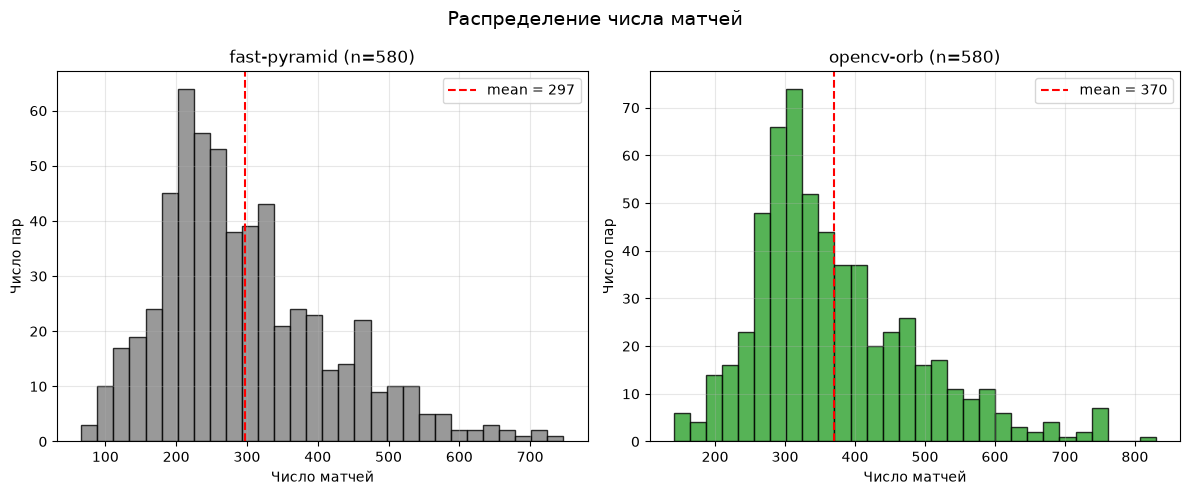

In [6]:
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 5))
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    matches = [p['matches'] for p in report['methods'][method]['pairs']]
    ax.hist(matches, bins=30, color=colors.get(method, 'gray'),
            edgecolor='black', alpha=0.8)
    ax.axvline(np.mean(matches), color='red', linestyle='--',
               label=f'mean = {np.mean(matches):.0f}')
    ax.set_xlabel('Число матчей')
    ax.set_ylabel('Число пар')
    ax.set_title(f'{method} (n={len(matches)})')
    ax.legend()

plt.suptitle('Распределение числа матчей', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Scatter по последовательностям: наш vs OpenCV (MMA@3)

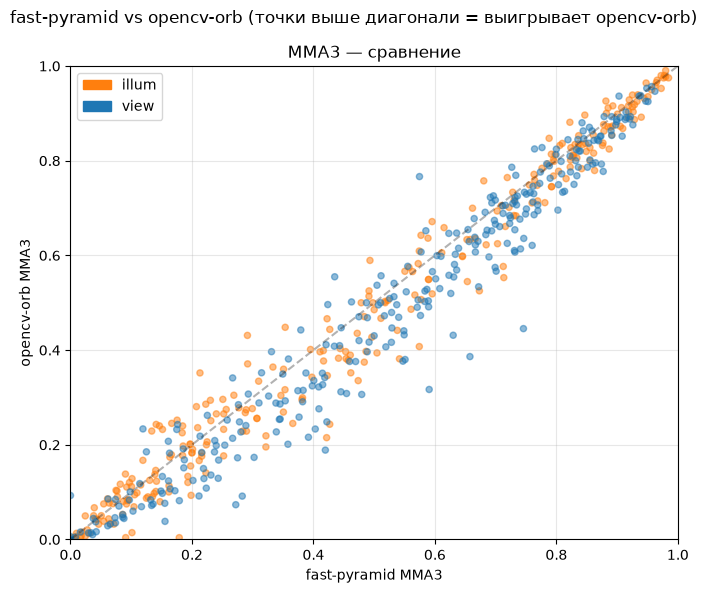

In [7]:
# Собираем метрики по каждой паре для каждого метода
def collect_pair_metrics(method):
    rows = []
    for p in report['methods'][method]['pairs']:
        rows.append({
            'sequence': p['sequence'],
            'target': p['target'],
            'key': f'{p["sequence"]}__{p["target"]}',
            'type': 'illum' if p['sequence'].startswith('i_') else 'view',
            'matches': p['matches'],
            'mma3': p['mma'][2],
            'mha3': p['mha'][2],
            'ms3': p['ms'][2],
        })
    return pd.DataFrame(rows)

df_pairs = {method: collect_pair_metrics(method) for method in methods}

if len(methods) >= 2:
    m1, m2 = methods[0], methods[1]
    d1 = df_pairs[m1].set_index('key')
    d2 = df_pairs[m2].set_index('key')
    common = d1.index.intersection(d2.index)

    fig, ax = plt.subplots(figsize=(7, 6))
    metric = 'mma3'
    x = d1.loc[common, metric].values
    y = d2.loc[common, metric].values
    types = d1.loc[common, 'type'].values
    colors_pts = ['tab:orange' if t == 'illum' else 'tab:blue' for t in types]

    ax.scatter(x, y, c=colors_pts, alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel(f'{m1} {metric.upper()}')
    ax.set_ylabel(f'{m2} {metric.upper()}')
    ax.set_title(f'{metric.upper()} — сравнение')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='tab:orange', label='illum'),
                       Patch(color='tab:blue', label='view')])

    plt.suptitle(f'{m1} vs {m2} (точки выше диагонали = выигрывает {m2})', fontsize=12)
    plt.tight_layout()
    plt.show()